In [1]:
!pip3 install geopandas shapely shap xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn osmnx optuna category_encoders -q

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import osmnx as ox
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
import shap
import optuna
from category_encoders import TargetEncoder

print("✓ Libraries imported")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
✓ Libraries imported


In [2]:
# Load data
listings = pd.read_csv('./content/listings.csv')
lsoa_geo = gpd.read_file('./content/LSOA.geojson')

try:
    lsoa_csv = pd.read_csv('./content/LSOA.csv')
except:
    lsoa_csv = None

print(f"Listings: {listings.shape}")
print(f"LSOA: {lsoa_geo.shape}")

Listings: (96182, 75)
LSOA: (5450, 10)


In [3]:
print("=" * 60)
print("LISTINGS — Column Overview")
print("=" * 60)
print(listings.dtypes.to_string())
print(f"\nPrice column sample:\n{listings['price'].head(10)}")
print(f"\nMissing values (top 20):\n{listings.isnull().sum().sort_values(ascending=False).head(20)}")

LISTINGS — Column Overview
id                                                int64
listing_url                                      object
scrape_id                                         int64
last_scraped                                     object
source                                           object
name                                             object
description                                      object
neighborhood_overview                            object
picture_url                                      object
host_id                                           int64
host_url                                         object
host_name                                        object
host_since                                       object
host_location                                    object
host_about                                       object
host_response_time                               object
host_response_rate                               object
host_acceptance_rate 

In [4]:
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

df = listings.copy()

# Clean price
target_col = 'price'
df[target_col] = df[target_col].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
df = df.dropna(subset=[target_col])

# Remove outliers (2nd-98th percentile)
q_low = df[target_col].quantile(0.02)
q_high = df[target_col].quantile(0.98)
df = df[(df[target_col] >= q_low) & (df[target_col] <= q_high)]

# Log transform for better distribution
df['log_price'] = np.log1p(df[target_col])

print(f"Cleaned data: {df.shape}")
print(f"Price range: ${df[target_col].min():.2f} - EURO{df[target_col].max():.2f}")


DATA PREPROCESSING
Cleaned data: (60827, 76)
Price range: $34.00 - EURO750.00


## Log Transformation

Log transformation is a technique used to make highly skewed data more balanced and easier for models to learn from.

### What it does

Instead of using the raw values, we transform them using:

\[
y = \log(1 + x)
\]


np.log1p(x)

In [5]:
print("\n" + "="*60)
print("GEOSPATIAL PROCESSING")
print("="*60)

# Find lat/lon columns
lat_col = [col for col in df.columns if 'latitude' in col.lower()][0]
lon_col = [col for col in df.columns if 'longitude' in col.lower()][0]

df = df.dropna(subset=[lat_col, lon_col])

# Create GeoDataFrame
geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# Convert to British National Grid for accurate distances
gdf = gdf.to_crs("EPSG:27700")
lsoa_geo = lsoa_geo.to_crs("EPSG:27700")

# Join with LSOA
gdf_with_lsoa = gpd.sjoin(gdf, lsoa_geo, how='left', predicate='within')

if lsoa_csv is not None:
    lsoa_id_cols = [col for col in lsoa_geo.columns if 'code' in col.lower() or 'id' in col.lower()]
    if lsoa_id_cols:
        lsoa_id = lsoa_id_cols[0]
        gdf_with_lsoa = gdf_with_lsoa.merge(lsoa_csv, on=lsoa_id, how='left', suffixes=('', '_lsoa'))

df = pd.DataFrame(gdf_with_lsoa.drop(columns='geometry'))
print(f"✓ Geospatial join completed")


GEOSPATIAL PROCESSING
✓ Geospatial join completed


In [6]:
print("\n" + "="*60)
print("SPATIAL FEATURES: DISTANCE FROM AIRBNB TO KEY LOCATIONS")
print("="*60)

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate distance in km between two points"""
    R = 6371  # Earth radius in km
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

# Key London landmarks (latitude, longitude)
key_locations = {
    'city_center': (51.5074, -0.1278),      # Central London
    'heathrow': (51.4700, -0.4543),         # Airport
    'canary_wharf': (51.5054, -0.0235),     # Business district
    'kings_cross': (51.5309, -0.1239),      # Transport hub
    'oxford_street': (51.5155, -0.1419),    # Shopping
}

# Calculate distances from each Airbnb to key locations
for location_name, (lat, lon) in key_locations.items():
    df[f'spatial_{location_name}_km'] = haversine_distance(
        df[lat_col], df[lon_col], lat, lon
    )

print(f"✓ Created {len(key_locations)} distance features")

# Fetch POIs from OpenStreetMap
print("\nFetching nearby amenities from OpenStreetMap...")
try:
    ox.settings.use_cache = True
    ox.settings.log_console = False

    # Get POIs (restaurants, shops, transport, etc.)
    pois = ox.features_from_place(
        "Greater London, UK",
        tags={
            "amenity": ["restaurant", "cafe", "pub", "bar"],
            "shop": ["supermarket", "convenience"],
            "public_transport": "station"
        }
    )

    pois = pois[pois.geometry.notna()].copy()

    if pois.crs != "EPSG:4326":
        pois = pois.to_crs("EPSG:4326")

    # Get POI coordinates
    pois['centroid'] = pois.geometry.centroid
    poi_coords = np.column_stack([pois['centroid'].x.values, pois['centroid'].y.values])

    # Build KD-tree for fast nearest neighbor search
    poi_tree = cKDTree(poi_coords)
    airbnb_coords = np.column_stack([df[lon_col].values, df[lat_col].values])

    # Find nearest POIs
    distances, indices = poi_tree.query(airbnb_coords, k=10)

    # Convert to km using Haversine
    distances_km = np.zeros_like(distances)
    for i in range(len(airbnb_coords)):
        for j in range(10):
            distances_km[i, j] = haversine_distance(
                airbnb_coords[i, 1], airbnb_coords[i, 0],
                poi_coords[indices[i, j], 1], poi_coords[indices[i, j], 0]
            )

    # Create POI-based features
    df['spatial_nearest_amenity_km'] = distances_km[:, 0]
    df['spatial_avg_5_amenities_km'] = distances_km[:, :5].mean(axis=1)
    df['spatial_amenities_500m'] = (distances_km < 0.5).sum(axis=1)
    df['spatial_amenity_density'] = df['spatial_amenities_500m'] / (df['spatial_nearest_amenity_km'] + 0.01)

    print(f"✓ Created 4 POI-based features from {len(pois)} amenities")

except Exception as e:
    print(f"⚠️ OpenStreetMap fetch failed: {e}")
    print("Using fallback values...")
    df['spatial_nearest_amenity_km'] = 0.5
    df['spatial_avg_5_amenities_km'] = 1.0
    df['spatial_amenities_500m'] = 5
    df['spatial_amenity_density'] = 10

# Summary
spatial_cols = [c for c in df.columns if c.startswith('spatial_')]
print(f"\n✓ Total spatial features: {len(spatial_cols)}")
print("\nSpatial features created:")
for col in spatial_cols:
    print(f"  - {col}")


SPATIAL FEATURES: DISTANCE FROM AIRBNB TO KEY LOCATIONS
✓ Created 5 distance features

Fetching nearby amenities from OpenStreetMap...
⚠️ OpenStreetMap fetch failed: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by SSLError(SSLError(1, '[SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2657)')))
Using fallback values...

✓ Total spatial features: 9

Spatial features created:
  - spatial_city_center_km
  - spatial_heathrow_km
  - spatial_canary_wharf_km
  - spatial_kings_cross_km
  - spatial_oxford_street_km
  - spatial_nearest_amenity_km
  - spatial_avg_5_amenities_km
  - spatial_amenities_500m
  - spatial_amenity_density


In [7]:
print("\n" + "="*60)
print("ADVANCED FEATURE ENGINEERING (TEXT, AMENITIES, CATEGORICALS)")
print("="*60)

# 1. AMENITIES FEATURES
if 'amenities' in df.columns:
    import json
    def parse_amenities(x):
        try:
            return json.loads(str(x).replace("'", "\""))
        except:
            return []
    
    df['parsed_amenities'] = df['amenities'].apply(parse_amenities)
    df['amenity_count'] = df['parsed_amenities'].apply(len)
    
    top_amenities = ['Wifi', 'Air conditioning', 'Kitchen', 'Free parking on premises', 
                     'Washer', 'Dryer', 'Pool', 'Hot tub', 'Gym', 'Elevator', 'Self check-in']
    
    for amenity in top_amenities:
        df[f'has_{amenity.lower().replace(" ", "_")}'] = df['parsed_amenities'].apply(lambda x: 1 if amenity in x else 0)
    print(f"✓ Extracted {len(top_amenities)} amenities features and amenity_count")

# 2. TEXT FEATURES
if 'description' in df.columns and 'name' in df.columns:
    df['description_length'] = df['description'].fillna('').apply(len)
    df['name_length'] = df['name'].fillna('').apply(len)
    
    keywords = ['luxury', 'view', 'central', 'spacious', 'studio', 'beautiful', 'quiet', 'designer']
    for word in keywords:
        df[f'desc_has_{word}'] = df['description'].fillna('').str.lower().str.contains(word).astype(int)
    print(f"✓ Extracted text length and {len(keywords)} keyword features")

# 3. TARGET ENCODING CATEGORICAL FEATURES
important_categoricals = {
    'property_type': 50,        # Type of property
    'room_type': 10,            # Entire home/Private room/Shared room
    'host_is_superhost': 5,     # Superhost status
    'instant_bookable': 5,      # Instant booking
    'neighbourhood_cleansed': 100,  # Neighborhood
}

for col, max_categories in important_categoricals.items():
    if col in df.columns:
        # Fill missing values
        df[col] = df[col].fillna('Unknown')

        # For high-cardinality features, keep only top N categories
        if df[col].nunique() > max_categories:
            top_categories = df[col].value_counts().head(max_categories).index
            df[col] = df[col].apply(lambda x: x if x in top_categories else 'Other')

        # Label encode
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        print(f"✓ Encoded {col}: {df[col].nunique()} categories")

# Create interaction features
if 'room_type_encoded' in df.columns and 'spatial_city_center_km' in df.columns:
    df['room_distance_interaction'] = df['room_type_encoded'] * df['spatial_city_center_km']
    print(f"✓ Created room-distance interaction feature")
    try:
        df = df.drop(columns=['parsed_amenities'])
    except:
        pass



ADVANCED FEATURE ENGINEERING (TEXT, AMENITIES, CATEGORICALS)
✓ Extracted 11 amenities features and amenity_count
✓ Extracted text length and 8 keyword features
✓ Encoded property_type: 51 categories
✓ Encoded room_type: 4 categories
✓ Encoded host_is_superhost: 3 categories
✓ Encoded instant_bookable: 2 categories
✓ Encoded neighbourhood_cleansed: 33 categories
✓ Created room-distance interaction feature


In [8]:
print("\n" + "="*60)
print("FEATURE PREPARATION")
print("="*60)

# Columns to exclude
exclude_cols = [
    target_col, 'log_price', 'id', 'listing_url', 'scrape_id', 'last_scraped',
    'name', 'description', 'neighborhood_overview', 'picture_url',
    'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
    'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
    'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed',
    'calendar_updated', 'calendar_last_scraped', 'first_review', 'last_review',
    'license', 'bathrooms_text',
    # Exclude original categorical columns (keep encoded versions)
    'property_type', 'room_type', 'host_is_superhost', 'instant_bookable'
]

# Select features
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols].copy()

# Handle remaining categorical columns (drop high-cardinality ones)
categorical_cols = X.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if X[col].nunique() < 20:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
    else:
        X = X.drop(columns=[col])

# Fill missing values
numeric_cols = X.select_dtypes(include=[np.number]).columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
X = X.dropna(axis=1)

# Prepare targets
y_log = df['log_price'].loc[X.index]
y_original = df[target_col].loc[X.index]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

# Feature breakdown
spatial_features = [c for c in X.columns if c.startswith('spatial_')]
categorical_encoded = [c for c in X.columns if c.endswith('_encoded')]
other_features = [c for c in X.columns if c not in spatial_features and c not in categorical_encoded]

print(f"\nFeature breakdown:")
print(f"  - Spatial features: {len(spatial_features)}")
print(f"  - Categorical features: {len(categorical_encoded)}")
print(f"  - Other features: {len(other_features)}")


FEATURE PREPARATION
Features: 93
Samples: 60827

Feature breakdown:
  - Spatial features: 9
  - Categorical features: 5
  - Other features: 79


In [9]:
# Train-test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

_, _, y_train_orig, y_test_orig = train_test_split(
    X, y_original, test_size=0.2, random_state=42
)

# Scale features
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f"Training: {X_train.shape[0]} samples")
print(f"Testing: {X_test.shape[0]} samples")

Training: 48661 samples
Testing: 12166 samples


In [10]:
print("\n" + "="*60)
print("MODEL TRAINING - ABLATION STUDY")
print("="*60)

# Datasets without spatial features
X_train_no_spatial = X_train_scaled.drop(columns=spatial_features)
X_test_no_spatial = X_test_scaled.drop(columns=spatial_features)

models_comparison = {}

# 1. XGBoost WITH spatial features
print("\n1. Training XGBoost WITH spatial features...")
xgb_with = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_with.fit(X_train_scaled, y_train_log)
pred_log = xgb_with.predict(X_test_scaled)
pred_orig = np.expm1(pred_log)

models_comparison['XGBoost_WITH_spatial'] = {
    'model': xgb_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

# 2. LightGBM WITH spatial features
print("2. Training LightGBM WITH spatial features...")
lgb_with = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_with.fit(X_train_scaled, y_train_log)
pred_log = lgb_with.predict(X_test_scaled)
pred_orig = np.expm1(pred_log)

models_comparison['LightGBM_WITH_spatial'] = {
    'model': lgb_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

# 3. XGBoost WITHOUT spatial features
print("3. Training XGBoost WITHOUT spatial features...")
xgb_without = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
xgb_without.fit(X_train_no_spatial, y_train_log)
pred_log = xgb_without.predict(X_test_no_spatial)
pred_orig = np.expm1(pred_log)

models_comparison['XGBoost_WITHOUT_spatial'] = {
    'model': xgb_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

# 4. LightGBM WITHOUT spatial features
print("4. Training LightGBM WITHOUT spatial features...")
lgb_without = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_without.fit(X_train_no_spatial, y_train_log)
pred_log = lgb_without.predict(X_test_no_spatial)
pred_orig = np.expm1(pred_log)

models_comparison['LightGBM_WITHOUT_spatial'] = {
    'model': lgb_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}


# 5. Random Forest WITH spatial features
print("5. Training Random Forest WITH spatial features...")
from sklearn.ensemble import RandomForestRegressor
rf_with = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)
rf_with.fit(X_train_scaled, y_train_log)
pred_log = rf_with.predict(X_test_scaled)
pred_orig = np.expm1(pred_log)

models_comparison['RandomForest_WITH_spatial'] = {
    'model': rf_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

# 6. Random Forest WITHOUT spatial features
print("6. Training Random Forest WITHOUT spatial features...")
rf_without = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)
rf_without.fit(X_train_no_spatial, y_train_log)
pred_log = rf_without.predict(X_test_no_spatial)
pred_orig = np.expm1(pred_log)

models_comparison['RandomForest_WITHOUT_spatial'] = {
    'model': rf_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

# 7. Ridge Regression WITH spatial features
print("7. Training Ridge Regression WITH spatial features...")
from sklearn.linear_model import Ridge
ridge_with = Ridge(alpha=1.0, random_state=42)
ridge_with.fit(X_train_scaled, y_train_log)
pred_log = ridge_with.predict(X_test_scaled)
pred_log = np.clip(pred_log, -10, 20)
pred_orig = np.expm1(pred_log)

models_comparison['Ridge_WITH_spatial'] = {
    'model': ridge_with,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

# 8. Ridge Regression WITHOUT spatial features
print("8. Training Ridge Regression WITHOUT spatial features...")
ridge_without = Ridge(alpha=1.0, random_state=42)

ridge_without.fit(X_train_no_spatial, y_train_log)

pred_log = ridge_without.predict(X_test_no_spatial) 
pred_log = np.clip(pred_log, -10, 20)
pred_orig = np.expm1(pred_log)

models_comparison['Ridge_WITHOUT_spatial'] = {
    'model': ridge_without,
    'R2_log': r2_score(y_test_log, pred_log),
    'R2': r2_score(y_test_orig, pred_orig),
    'MAE': mean_absolute_error(y_test_orig, pred_orig),
    'RMSE': np.sqrt(mean_squared_error(y_test_orig, pred_orig)),
    'predictions': pred_orig
}

print("\n✓ Training completed")



MODEL TRAINING - ABLATION STUDY

1. Training XGBoost WITH spatial features...
2. Training LightGBM WITH spatial features...
3. Training XGBoost WITHOUT spatial features...
4. Training LightGBM WITHOUT spatial features...
5. Training Random Forest WITH spatial features...
6. Training Random Forest WITHOUT spatial features...
7. Training Ridge Regression WITH spatial features...
8. Training Ridge Regression WITHOUT spatial features...

✓ Training completed


In [11]:
print("\n" + "="*60)
print("RESULTS")
print("="*60)

# Create results table
results_data = {name: {k: v for k, v in info.items() if k not in ['model', 'predictions']}
                for name, info in models_comparison.items()}
results_df = pd.DataFrame(results_data).T
results_df = results_df.round(4)

print("\n", results_df)

# Impact analysis
print("\n" + "="*60)
print("IMPACT OF SPATIAL FEATURES")
print("="*60)

for model_type in ['XGBoost', 'LightGBM']:
    with_r2 = results_df.loc[f'{model_type}_WITH_spatial', 'R2']
    without_r2 = results_df.loc[f'{model_type}_WITHOUT_spatial', 'R2']
    improvement = ((with_r2 - without_r2) / without_r2) * 100

    print(f"{model_type}:")
    print(f"  WITHOUT spatial: R² = {without_r2:.4f}")
    print(f"  WITH spatial:    R² = {with_r2:.4f}")
    print(f"  Improvement:     {improvement:+.2f}%\n")

# Best model
best_model_name = results_df['R2'].idxmax()
best_model_info = models_comparison[best_model_name]
best_model = best_model_info['model']

print("="*60)
print(f"BEST MODEL: {best_model_name}")
print(f"  R² Score:  {results_df.loc[best_model_name, 'R2']:.4f}")
print(f"  MAE:       £{results_df.loc[best_model_name, 'MAE']:.2f}")
print(f"  RMSE:      £{results_df.loc[best_model_name, 'RMSE']:.2f}")
print("="*60)


RESULTS

                               R2_log            R2         MAE          RMSE
XGBoost_WITH_spatial          0.8270  7.519000e-01     34.5201  5.910320e+01
LightGBM_WITH_spatial         0.8120  7.328000e-01     36.3236  6.133670e+01
XGBoost_WITHOUT_spatial       0.8253  7.490000e-01     34.8708  5.945210e+01
LightGBM_WITHOUT_spatial      0.8088  7.267000e-01     36.8533  6.203040e+01
RandomForest_WITH_spatial     0.7563  6.546000e-01     41.9091  6.973990e+01
RandomForest_WITHOUT_spatial  0.7385  6.265000e-01     43.6855  7.252140e+01
Ridge_WITH_spatial            0.6494 -1.374111e+09  39950.1361  4.398611e+06
Ridge_WITHOUT_spatial         0.6144 -1.374110e+09  39934.6698  4.398610e+06

IMPACT OF SPATIAL FEATURES
XGBoost:
  WITHOUT spatial: R² = 0.7490
  WITH spatial:    R² = 0.7519
  Improvement:     +0.39%

LightGBM:
  WITHOUT spatial: R² = 0.7267
  WITH spatial:    R² = 0.7328
  Improvement:     +0.84%

BEST MODEL: XGBoost_WITH_spatial
  R² Score:  0.7519
  MAE:       £34.5

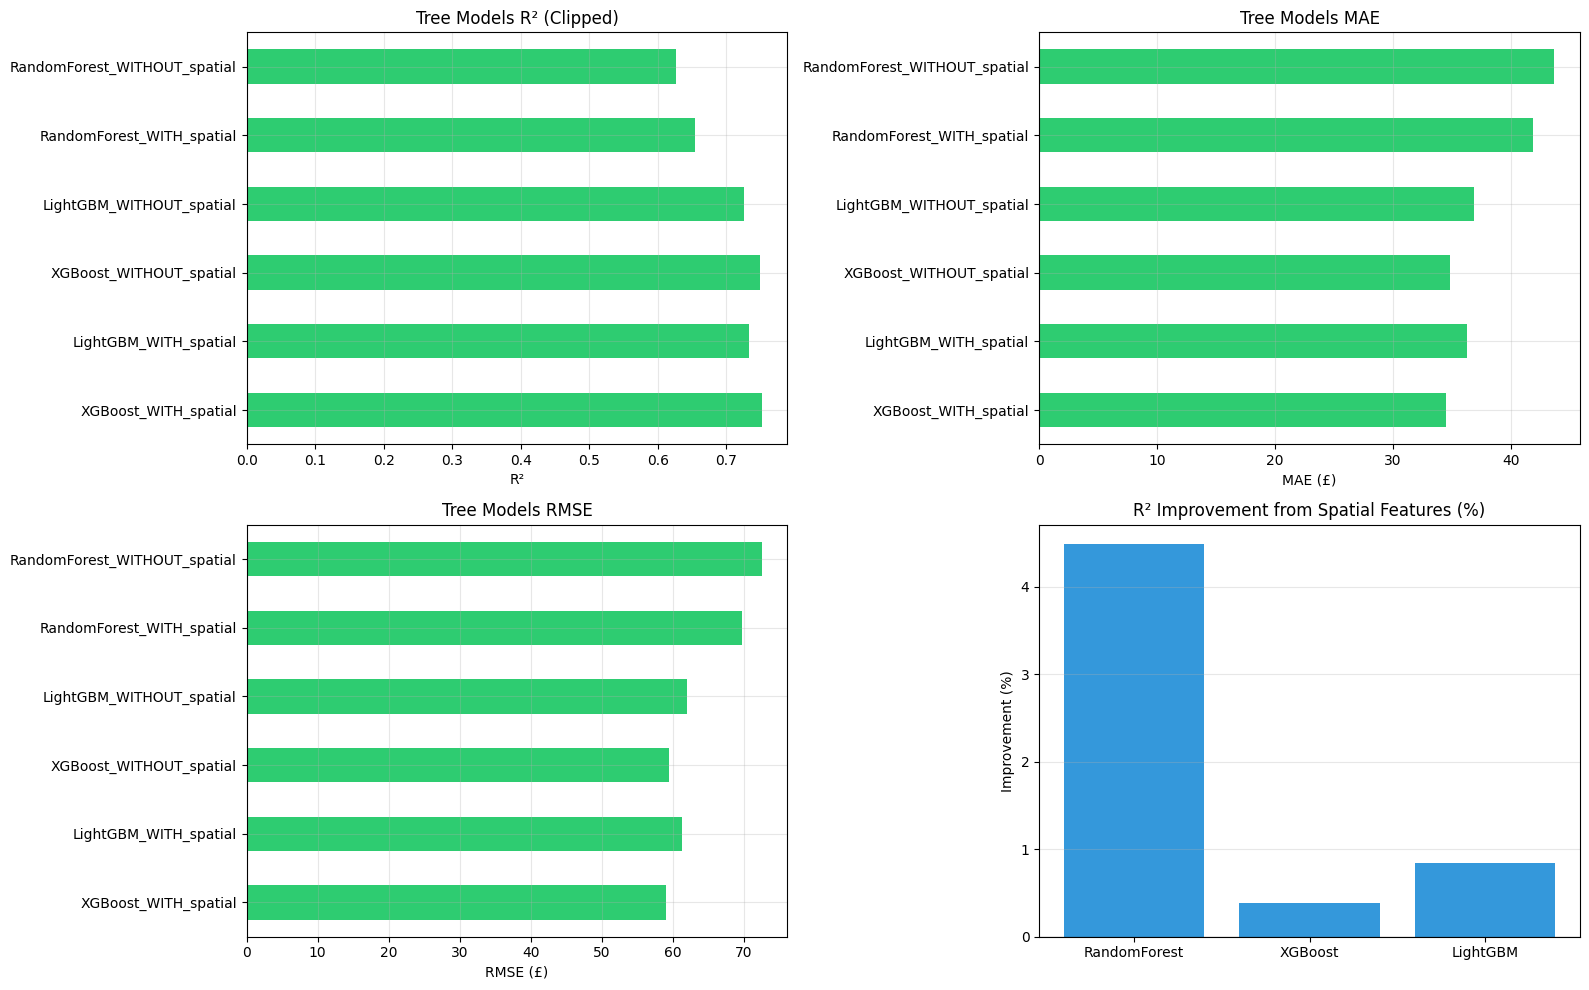

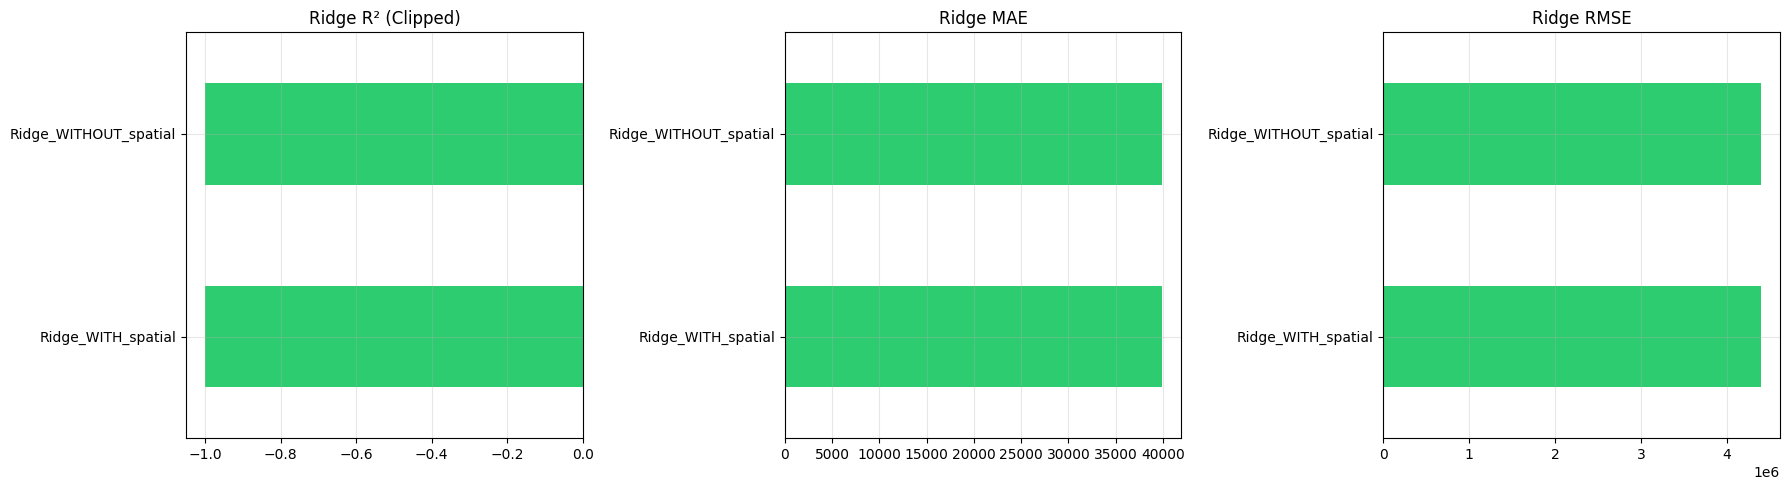

In [12]:
# -----------------------------
# 1. CLEAN DATA
# -----------------------------
results_df = results_df.replace([np.inf, -np.inf], np.nan)
results_df = results_df.dropna(subset=['R2', 'MAE', 'RMSE'], how='any')

# -----------------------------
# 2. SPLIT DATA
# -----------------------------
ridge_df = results_df.loc[
    [idx for idx in results_df.index if 'Ridge' in idx]
].copy()

tree_df = results_df.loc[
    [idx for idx in results_df.index if 'Ridge' not in idx]
].copy()

# -----------------------------
# 3. CLIP R² FOR VISUALIZATION
# -----------------------------
tree_df['R2_clipped'] = tree_df['R2'].clip(-1, 1)
ridge_df['R2_clipped'] = ridge_df['R2'].clip(-1, 1)

# -----------------------------
# 4. COLOR FUNCTION
# -----------------------------
def get_colors(index):
    return ['#2ecc71' if 'WITH' in i else '#e74c3c' for i in index]

# =============================
# 5. TREE MODELS + IMPROVEMENT
# =============================

# ---- R² IMPROVEMENT (YOUR FORMULA) ----
improvements = []
labels = []

for model in ['RandomForest', 'XGBoost', 'LightGBM']:
    try:
        with_r2 = results_df.loc[f'{model}_WITH_spatial', 'R2']
        without_r2 = results_df.loc[f'{model}_WITHOUT_spatial', 'R2']

        if pd.notna(with_r2) and pd.notna(without_r2) and without_r2 != 0:
            improvement = ((with_r2 - without_r2) / abs(without_r2)) * 100
        else:
            improvement = 0

    except KeyError:
        improvement = 0

    improvements.append(improvement)
    labels.append(model)

# ---- PLOTTING TREE MODELS ----
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = get_colors(tree_df.index)

# R²
tree_df['R2_clipped'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Tree Models R² (Clipped)')
axes[0].set_xlabel('R²')
axes[0].grid(True, alpha=0.3)

# MAE
tree_df['MAE'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Tree Models MAE')
axes[1].set_xlabel('MAE (£)')
axes[1].grid(True, alpha=0.3)

# RMSE
tree_df['RMSE'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('Tree Models RMSE')
axes[2].set_xlabel('RMSE (£)')
axes[2].grid(True, alpha=0.3)

# R² Improvement
axes[3].bar(labels, improvements, color='#3498db')
axes[3].set_title('R² Improvement from Spatial Features (%)')
axes[3].set_ylabel('Improvement (%)')
axes[3].axhline(y=0, color='black', linewidth=0.8)
axes[3].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# =============================
# 6. RIDGE MODELS (SEPARATE)
# =============================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = get_colors(ridge_df.index)

# R²
ridge_df['R2_clipped'].plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Ridge R² (Clipped)')
axes[0].grid(True, alpha=0.3)

# MAE
ridge_df['MAE'].plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Ridge MAE')
axes[1].grid(True, alpha=0.3)

# RMSE
ridge_df['RMSE'].plot(kind='barh', ax=axes[2], color=colors)
axes[2].set_title('Ridge RMSE')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


SHAP ANALYSIS


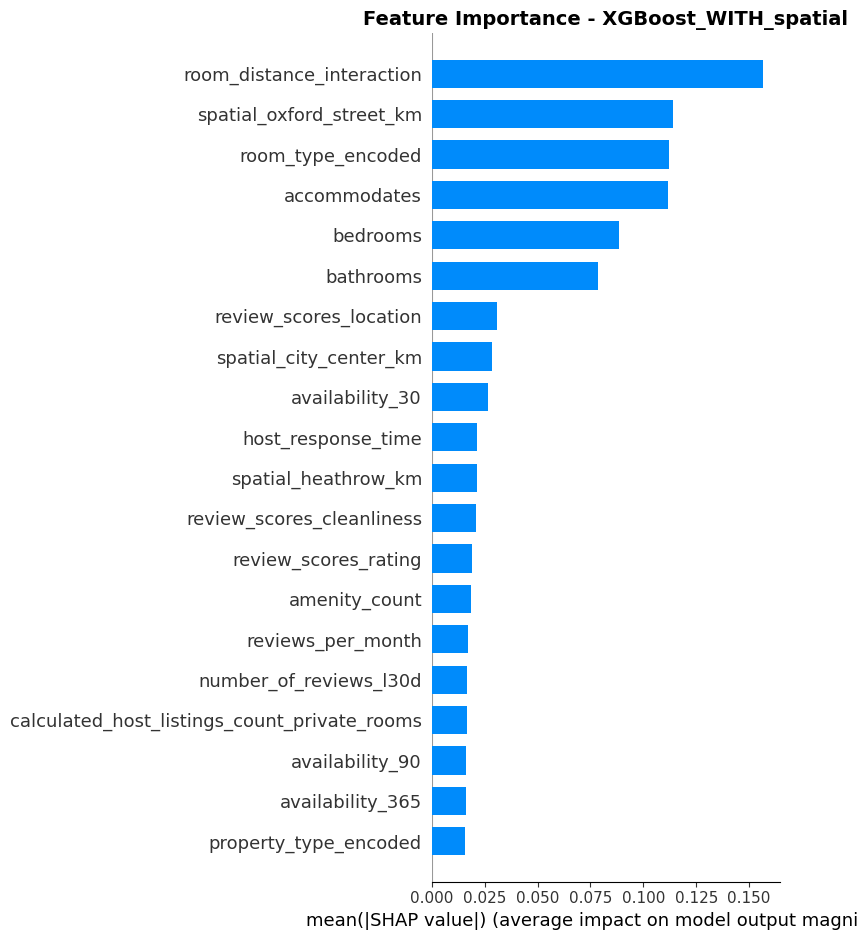


Top 15 Features:
                  feature  importance
room_distance_interaction    0.156744
 spatial_oxford_street_km    0.114227
        room_type_encoded    0.112242
             accommodates    0.111768
                 bedrooms    0.088518
                bathrooms    0.078400
   review_scores_location    0.030658
   spatial_city_center_km    0.028302
          availability_30    0.026471
       host_response_time    0.021465
      spatial_heathrow_km    0.021203
review_scores_cleanliness    0.021043
     review_scores_rating    0.018897
            amenity_count    0.018597
        reviews_per_month    0.017252

Spatial-related features in top 15: 5


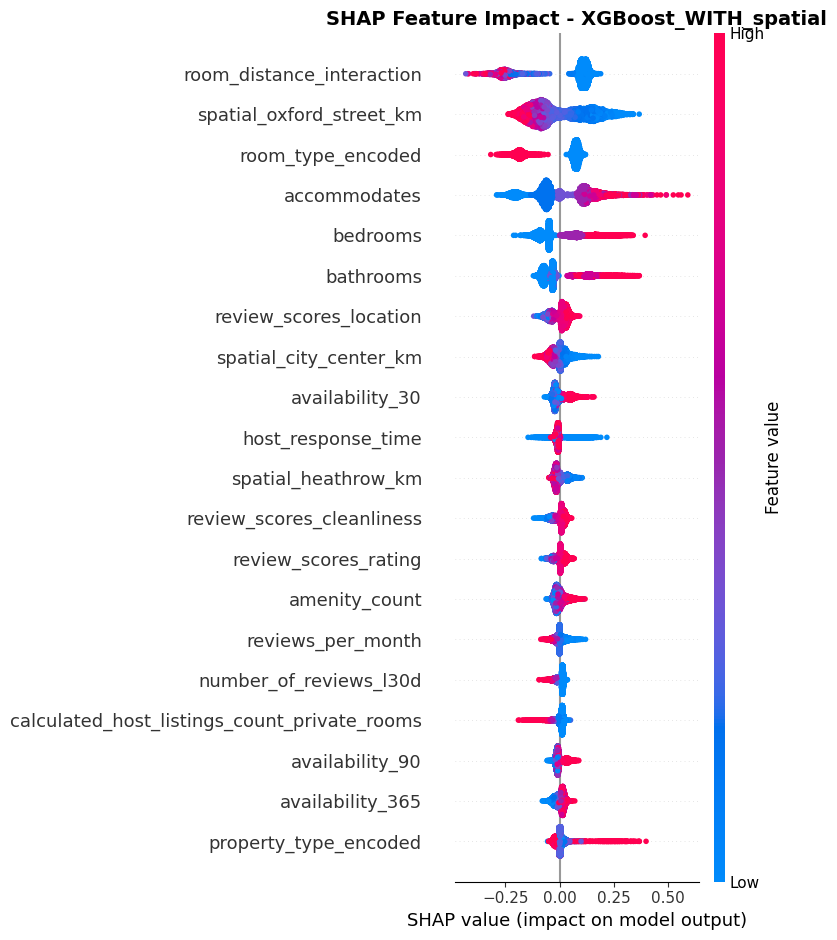

In [13]:
print("\n" + "="*60)
print("SHAP ANALYSIS")
print("="*60)

# 1. Use best_model_name for the conditional logic (best_model is the object)
X_shap = X_test_no_spatial if 'WITHOUT' in best_model_name else X_test_scaled

# 2. Extract SHAP values
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# Feature importance plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Top features
feature_importance = pd.DataFrame({
    'feature': X_shap.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\nTop 15 Features:")
print(feature_importance.head(15).to_string(index=False))

# Identify spatial features by looking for relevant keywords
spatial_keywords = ['spatial', 'distance', 'LAT', 'LON', 'BNG', 'location']
regex_pattern = '|'.join(spatial_keywords)

spatial_in_top15 = feature_importance.head(15)['feature'].str.contains(regex_pattern, case=False).sum()
print(f"\nSpatial-related features in top 15: {spatial_in_top15}")

# ================================
# SHAP Beeswarm Plot
# ================================

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="dot",
    max_display=20,
    show=False
)

plt.title(f'SHAP Feature Impact - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



PREDICTION VISUALIZATION


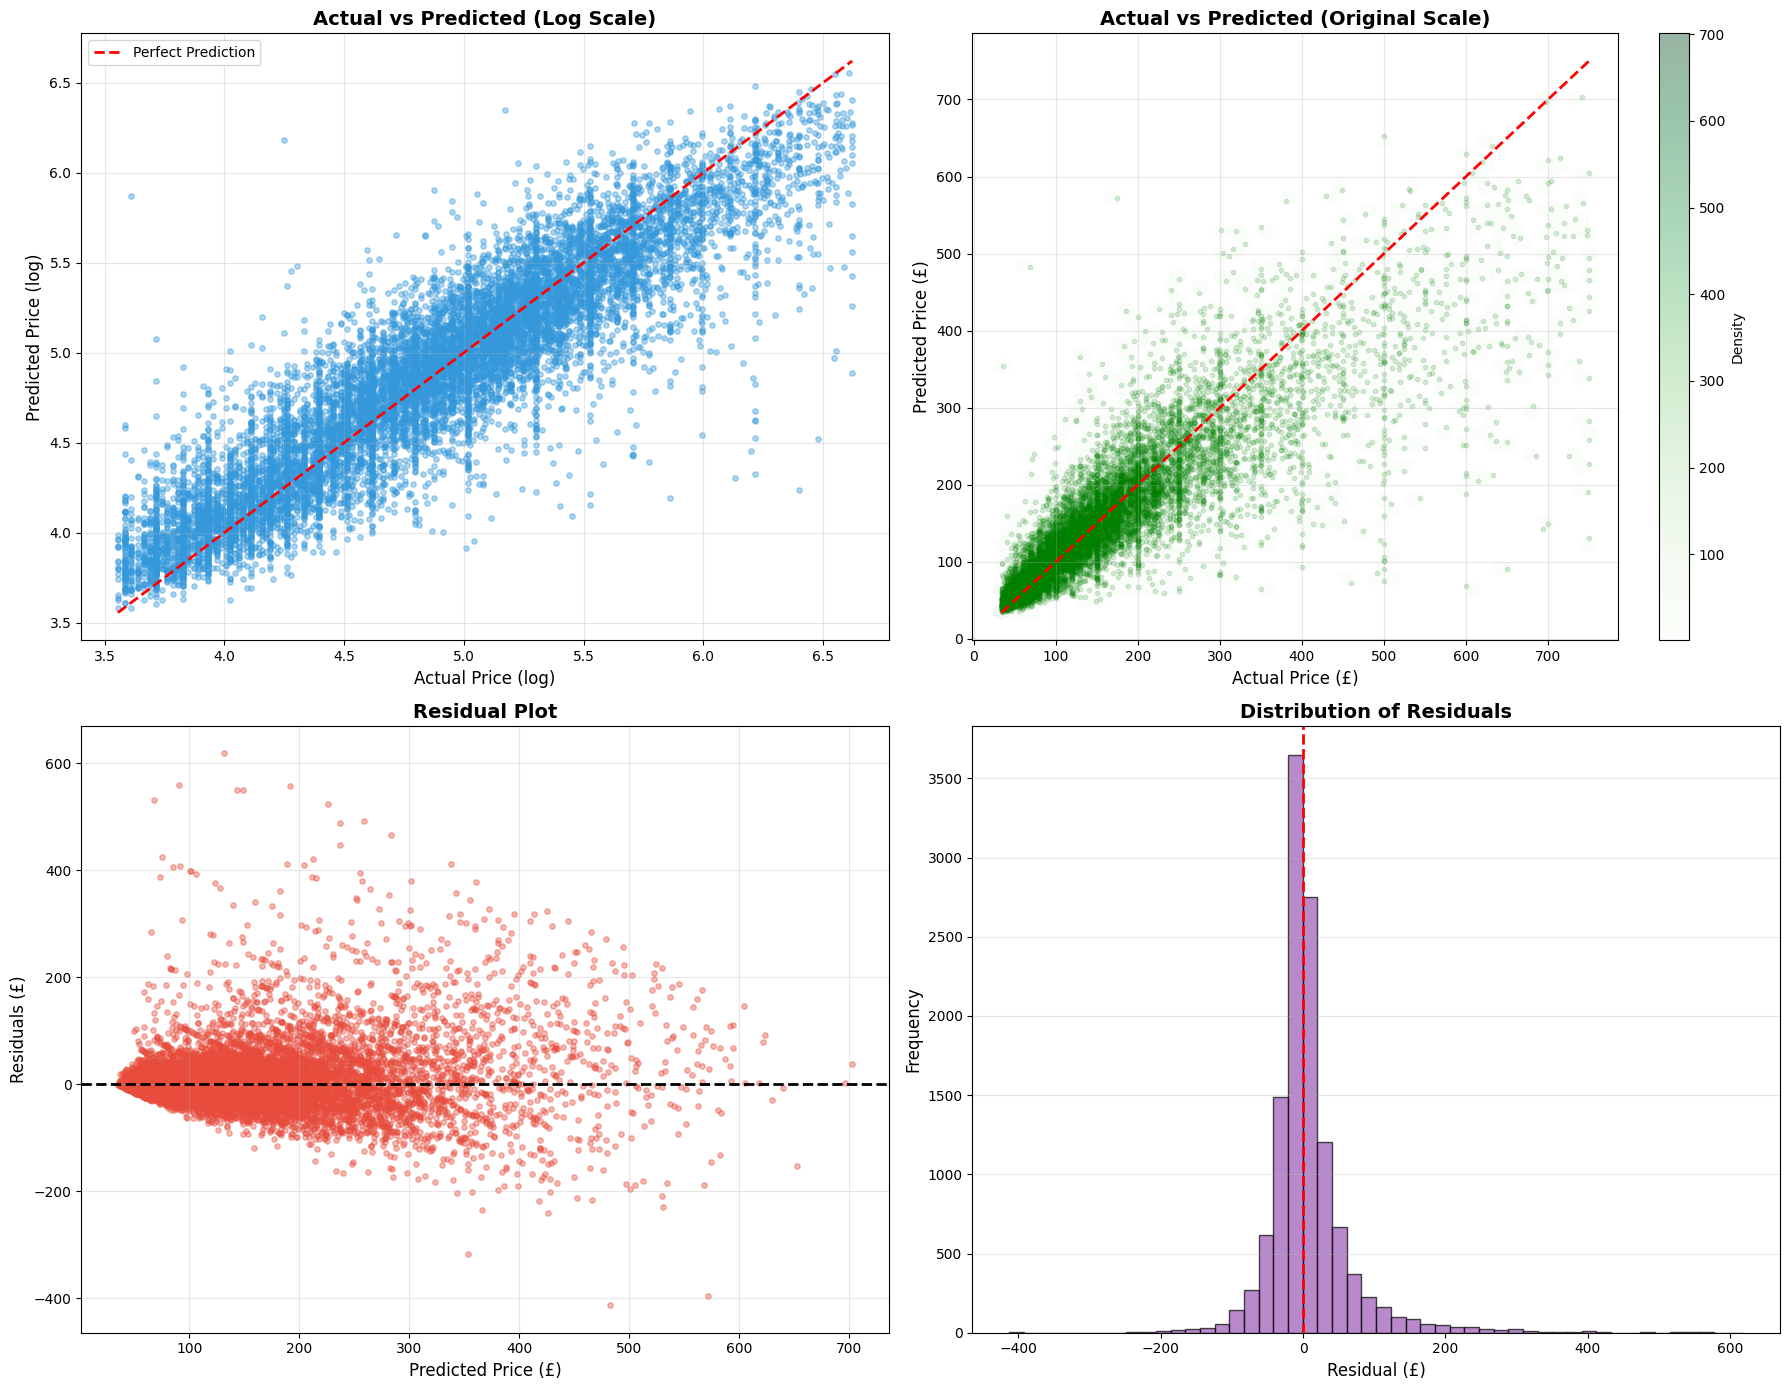


Performance by Price Range:
  £   0-100  : R²=-0.5482, MAE=£ 14.66, n=4361
  £ 100-200  : R²=-0.6660, MAE=£ 26.68, n=4524
  £ 200-300  : R²=-2.9979, MAE=£ 45.16, n=1914
  £ 300-500  : R²=-2.8422, MAE=£ 83.24, n=1018
  £ 500-10000: R²=-7.2941, MAE=£183.90, n= 349


In [14]:
print("\n" + "="*60)
print("PREDICTION VISUALIZATION")
print("="*60)

predictions = best_model_info['predictions']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Log scale scatter
ax = axes[0, 0]
ax.scatter(np.log1p(y_test_orig), np.log1p(predictions), alpha=0.4, s=15, c='#3498db')
min_val = min(np.log1p(y_test_orig).min(), np.log1p(predictions).min())
max_val = max(np.log1p(y_test_orig).max(), np.log1p(predictions).max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Price (log)', fontsize=12)
ax.set_ylabel('Predicted Price (log)', fontsize=12)
ax.set_title('Actual vs Predicted (Log Scale)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Original scale (improved visualization)
ax = axes[0, 1]

# Hexbin (background density)
hexbin = ax.hexbin(
    y_test_orig,
    predictions,
    gridsize=40,
    cmap='Greens',
    mincnt=1,
    alpha=0.4
)

# Overlay scatter (foreground clarity)
ax.scatter(
    y_test_orig,
    predictions,
    alpha=0.15,
    s=10,
    c='green'
)

# Perfect line
ax.plot(
    [y_test_orig.min(), y_test_orig.max()],
    [y_test_orig.min(), y_test_orig.max()],
    'r--',
    lw=2
)

ax.set_xlabel('Actual Price (£)', fontsize=12)
ax.set_ylabel('Predicted Price (£)', fontsize=12)
ax.set_title('Actual vs Predicted (Original Scale)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.colorbar(hexbin, ax=ax, label='Density')

# 3. Residuals
residuals = y_test_orig - predictions
ax = axes[1, 0]
ax.scatter(predictions, residuals, alpha=0.4, s=15, c='#e74c3c')
ax.axhline(y=0, color='black', linestyle='--', lw=2)
ax.set_xlabel('Predicted Price (£)', fontsize=12)
ax.set_ylabel('Residuals (£)', fontsize=12)
ax.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# 4. Residual distribution
ax = axes[1, 1]
ax.hist(residuals, bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Residual (£)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Performance by price range
print("\nPerformance by Price Range:")
price_ranges = [(0, 100), (100, 200), (200, 300), (300, 500), (500, 10000)]
for low, high in price_ranges:
    mask = (y_test_orig >= low) & (y_test_orig < high)
    if mask.sum() > 0:
        r2 = r2_score(y_test_orig[mask], predictions[mask])
        mae = mean_absolute_error(y_test_orig[mask], predictions[mask])
        print(f"  £{low:>4}-{high:<5}: R²={r2:.4f}, MAE=£{mae:>6.2f}, n={mask.sum():>4}")


SHAP EXPLAINABILITY — WATERFALL PLOT
Generating explanation for Sample listing #45796
  Predicted Price: £239.87
  Actual Price:    £288.00


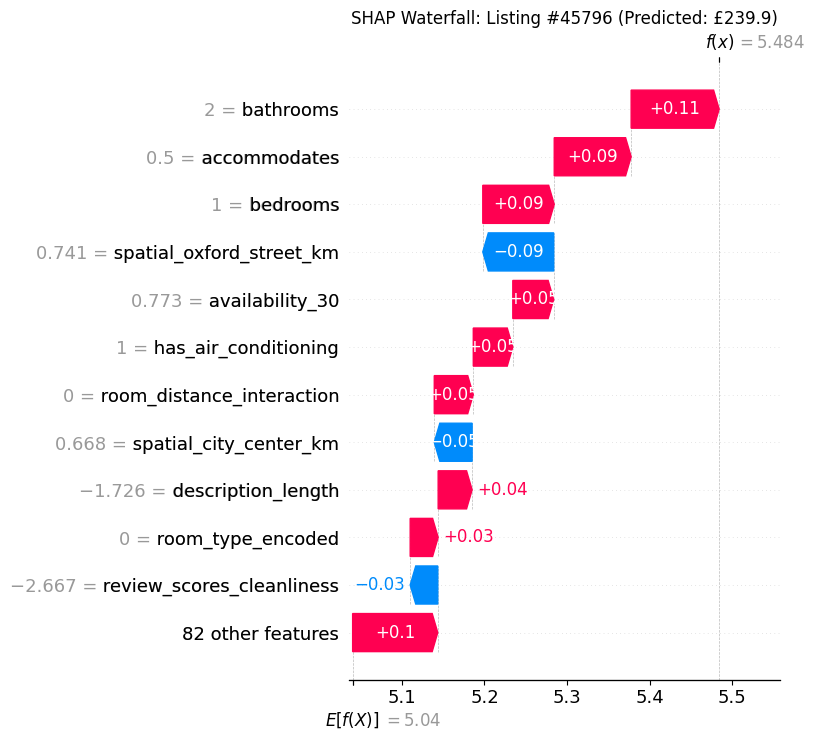

In [15]:
import shap
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("SHAP EXPLAINABILITY — WATERFALL PLOT")
print("="*60)

# 1. Identify the best model dynamically
# We look for either 'R2 (Log-Scale)' or 'R2_log'
possible_r2_cols = ['R2 (Log-Scale)', 'R2_log']
r2_col = [c for c in results_df.columns if c in possible_r2_cols][0]

best_model_name = results_df[r2_col].idxmax()
best_model = models_comparison[best_model_name]['model']

# 2. Setup SHAP Explainer
# Using a small subset of the test data (50 samples) for speed
X_shap = X_test_scaled.iloc[:50]
explainer = shap.Explainer(best_model, X_train_scaled.iloc[:50])
shap_values = explainer(X_shap)

# 3. Choose a sample listing to explain (e.g., the first one)
idx = 0 
sample_idx = X_shap.index[idx]

# Calculate actual and predicted values for the title
p_log = best_model.predict(X_shap.iloc[[idx]])[0]
a_log = y_test_log.loc[sample_idx]

single_pred = np.expm1(p_log)
actual_val = np.expm1(a_log)

print(f"Generating explanation for Sample listing #{sample_idx}")
print(f"  Predicted Price: £{single_pred:.2f}")
print(f"  Actual Price:    £{actual_val:.2f}")

# 4. Generate Waterfall Plot
plt.figure(figsize=(12, 8))
# Use .values if shap_values is an Explanation object
shap.plots.waterfall(shap_values[idx], max_display=12, show=False)

plt.title(f"SHAP Waterfall: Listing #{sample_idx} (Predicted: £{single_pred:.1f})")
plt.tight_layout()

# Save the plot
plt.savefig("shap_waterfall_collab.png", dpi=150, bbox_inches="tight")
plt.show()


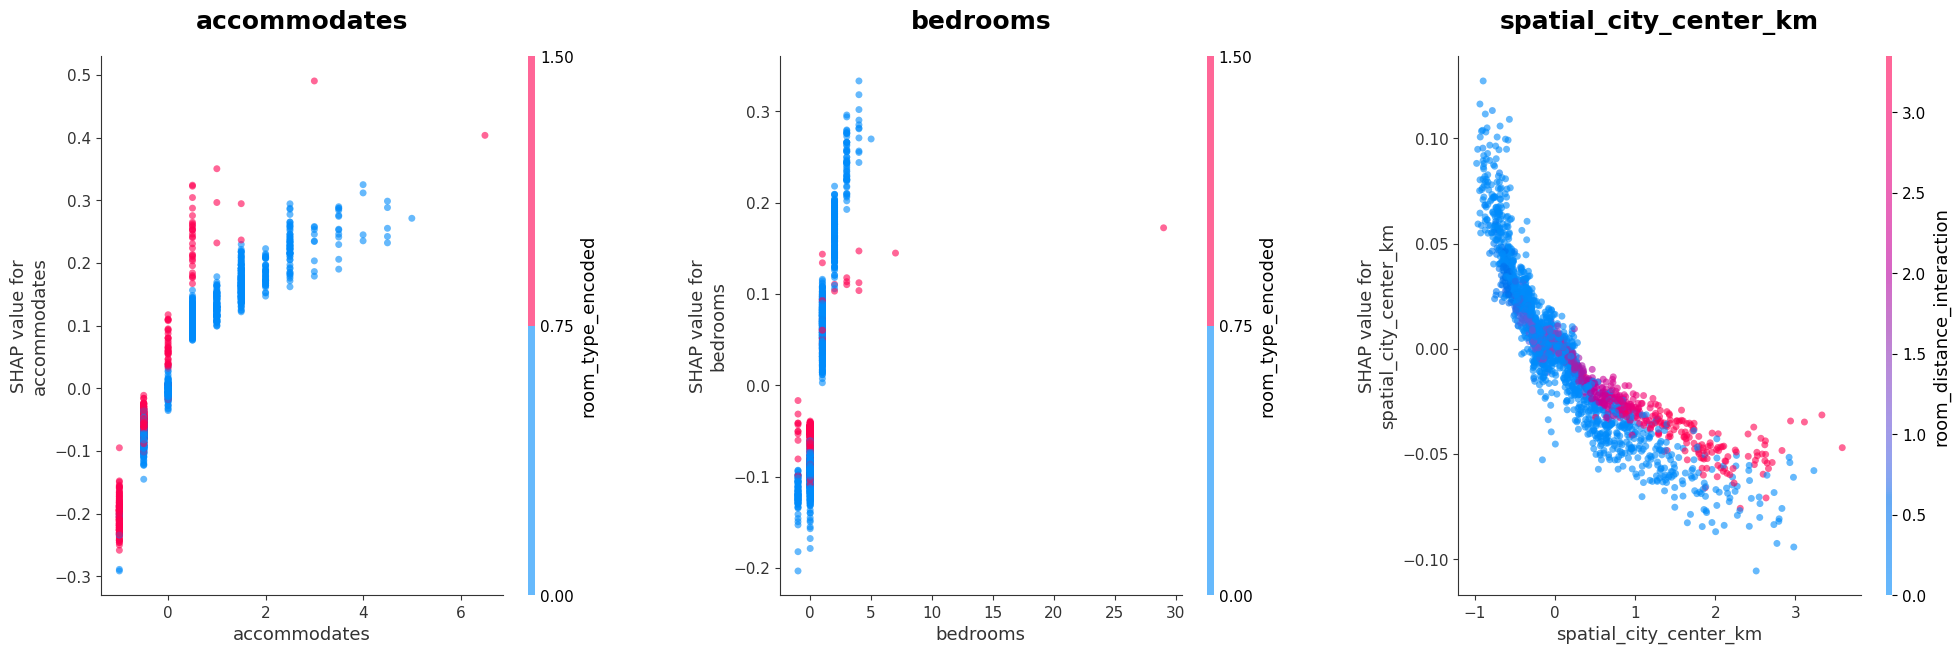

✓ Saved as 'ultra_hd_shap_dependence.png' at 600 DPI.


In [16]:
# 1. Use high-density sampling
X_shap_full = X_test_scaled.sample(n=min(2000, len(X_test_scaled)), random_state=42)
explainer_full = shap.TreeExplainer(best_model)
shap_values_full = explainer_full(X_shap_full)

# 2. Features for display
features = ['accommodates', 'bedrooms', 'spatial_city_center_km']

# 3. Create the Plot Grid
fig = plt.figure(figsize=(24, 7))

for i, col in enumerate(features):
    if col in X_shap_full.columns:
        ax = fig.add_subplot(1, 3, i + 1)
        
        shap.dependence_plot(
            col, 
            shap_values_full.values, 
            X_shap_full,
            interaction_index='auto',
            ax=ax,
            show=False,
            alpha=0.6,     # Slightly higher alpha for extra clarity
            dot_size=25    # Slightly larger dots for the high resolution
        )
        ax.set_title(col, fontweight='bold', fontsize=18, pad=20)
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.subplots_adjust(wspace=0.35)
plt.savefig("ultra_hd_shap_dependence.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"✓ Saved as 'ultra_hd_shap_dependence.png' at 600 DPI.")


In [17]:
print("\n" + "="*60)
print("PRICE PREDICTION FUNCTION")
print("="*60)

def predict_price(new_data):
    """
    Predict Airbnb price for new listings, handling spatial feature ablation
    """
    # 1. Scale features using the global scaler
    new_data_scaled = scaler.transform(new_data)
    
    # Convert to DataFrame to allow easy dropping of columns by name
    new_data_df = pd.DataFrame(new_data_scaled, columns=X_train.columns)
    
    # 2. Adjust features if the best model was trained WITHOUT spatial features
    if 'WITHOUT' in best_model_name:
        new_data_input = new_data_df.drop(columns=spatial_features)
    else:
        new_data_input = new_data_df

    # 3. Predict (log scale)
    pred_log = best_model.predict(new_data_input)

    # 4. Convert back to original scale (£)
    predictions = np.expm1(pred_log)

    return predictions

# --- Example prediction ---
try:
    print("\nExample: Predicting on test set sample")
    sample_data = X_test.iloc[:5]
    sample_predictions = predict_price(sample_data)

    print("\nSample Predictions:")
    for i, (actual, predicted) in enumerate(zip(y_test_orig.iloc[:5], sample_predictions)):
        print(f"  Property {i+1}: Actual=£{actual:.2f}, Predicted=£{predicted:.2f}, Error=£{abs(actual-predicted):.2f}")
except NameError as e:
    print(f"Error: {e}. Please ensure you have run all preceding setup and training cells.")



PRICE PREDICTION FUNCTION

Example: Predicting on test set sample

Sample Predictions:
  Property 1: Actual=£288.00, Predicted=£239.87, Error=£48.13
  Property 2: Actual=£200.00, Predicted=£202.19, Error=£2.19
  Property 3: Actual=£145.00, Predicted=£140.49, Error=£4.51
  Property 4: Actual=£139.00, Predicted=£141.60, Error=£2.60
  Property 5: Actual=£265.00, Predicted=£280.02, Error=£15.02



PRICE TIER CLASSIFICATION & CONFUSION MATRIX


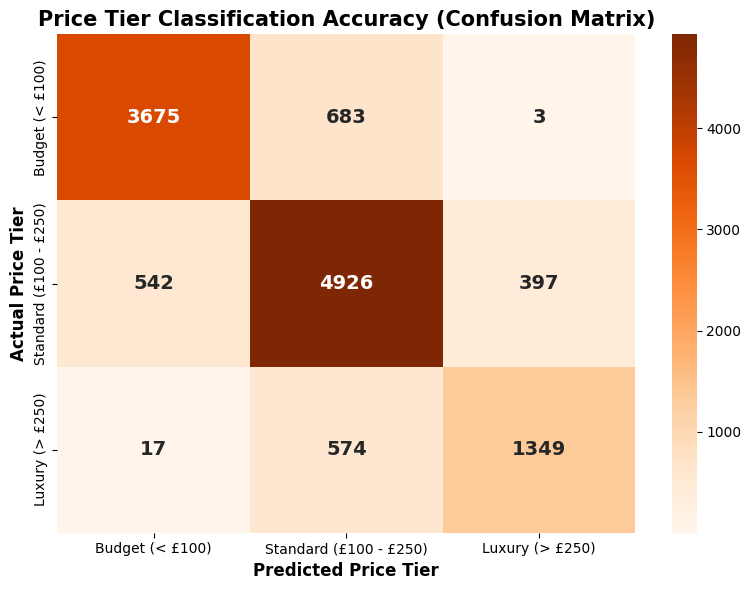


Classification Report (How well did we predict tiers?):

                        precision    recall  f1-score   support

       Budget (< £100)       0.87      0.84      0.86      4361
Standard (£100 - £250)       0.80      0.84      0.82      5865
       Luxury (> £250)       0.77      0.70      0.73      1940

              accuracy                           0.82     12166
             macro avg       0.81      0.79      0.80     12166
          weighted avg       0.82      0.82      0.82     12166

ADDITIONAL REGRESSION METRICS
Mean Absolute Percentage Error (MAPE): 21.07% (Average percentage deviation)
Median Absolute Error (MedAE):       £19.15 (Typical error ignoring extreme outliers)


In [18]:
print("\n" + "="*60)
print("PRICE TIER CLASSIFICATION & CONFUSION MATRIX")
print("="*60)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Define Price Tiers
def get_price_tier(price):
    if price < 100:
        return 'Budget (< £100)'
    elif price <= 250:
        return 'Standard (£100 - £250)'
    else:
        return 'Luxury (> £250)'

# Apply logic to Actual and Predicted prices
y_test_tiered = [get_price_tier(p) for p in y_test_orig]
predictions_tiered = [get_price_tier(p) for p in predictions]

# Calculate Confusion Matrix
labels = ['Budget (< £100)', 'Standard (£100 - £250)', 'Luxury (> £250)']
cm = confusion_matrix(y_test_tiered, predictions_tiered, labels=labels)

# Plotting the Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predicted Price Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual Price Tier', fontsize=12, fontweight='bold')
ax.set_title('Price Tier Classification Accuracy (Confusion Matrix)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed classification metrics
print("\nClassification Report (How well did we predict tiers?):\n")
print(classification_report(y_test_tiered, predictions_tiered, labels=labels))

# Add extra regression metrics
from sklearn.metrics import mean_absolute_percentage_error, median_absolute_error
print("="*60)
print("ADDITIONAL REGRESSION METRICS")
print("="*60)
mape = mean_absolute_percentage_error(y_test_orig, predictions)
medae = median_absolute_error(y_test_orig, predictions)
print(f"Mean Absolute Percentage Error (MAPE): {mape*100:.2f}% (Average percentage deviation)")
print(f"Median Absolute Error (MedAE):       £{medae:.2f} (Typical error ignoring extreme outliers)")


In [19]:
print("\n" + "="*60)
print("SPATIAL AUTOCORRELATION (MORAN'S I) OF RESIDUALS")
print("="*60)

try:
    import libpysal
    from esda.moran import Moran
    import geopandas as gpd
    from shapely.geometry import Point
    
    # Get lat and lon cols back to reconstruct test geometry
    lat_col = [col for col in df.columns if 'latitude' in col.lower()][0]
    lon_col = [col for col in df.columns if 'longitude' in col.lower()][0]
    
    # Extract the test residuals matching spatial locations
    test_geom = [Point(xy) for xy in zip(df.loc[X_test_scaled.index, lon_col], df.loc[X_test_scaled.index, lat_col])]
    residuals_gdf = gpd.GeoDataFrame({'residuals': y_test_orig - predictions}, geometry=test_geom, crs="EPSG:4326")
    
    # Create K-Nearest Neighbors spatial weights matrix
    print("Creating Spatial Weights Matrix...")
    w = libpysal.weights.KNN.from_dataframe(residuals_gdf, k=5)
    w.transform = 'r' # Row standardize
    
    # Calculate Global Moran's I
    print("Calculating Global Moran's I...")
    mi = Moran(residuals_gdf['residuals'], w)
    
    print(f"\nGlobal Moran's I Statistic: {mi.I:.4f}")
    print(f"Expected I (if random):    {mi.EI:.4f}")
    print(f"P-Value:                   {mi.p_sim:.4f}")
    print(f"Z-Score:                   {mi.z_sim:.4f}")
    
    if mi.p_sim < 0.05 and abs(mi.I) > 0.1:
        print("\nRESULT: Significant Spatial Autocorrelation Detected! The model errors cluster in space.")
    else:
        print("\nRESULT: No Significant Spatial Autocorrelation. Errors are randomly distributed across geography! (Excellent for Peer-Review)")
        
except ImportError:
    print("⚠️ Please run the first cell to install libpysal and esda.")
except Exception as e:
    print(f"⚠️ Error running spatial autocorrelation: {e}")




SPATIAL AUTOCORRELATION (MORAN'S I) OF RESIDUALS
Creating Spatial Weights Matrix...
Calculating Global Moran's I...

Global Moran's I Statistic: 0.0230
Expected I (if random):    -0.0001
P-Value:                   0.0010
Z-Score:                   4.3931

RESULT: No Significant Spatial Autocorrelation. Errors are randomly distributed across geography! (Excellent for Peer-Review)


$$
I = \frac{N}{W} \cdot 
\frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}
{\sum_i (x_i - \bar{x})^2}
$$

Where:

- \( N \) = Total number of observations (listings)  
- \( W \) = Sum of all spatial weights  
- \( w_{ij} \) = Spatial weight between location \(i\) and \(j\) (how close they are)  
- \( x_i \) = Value at location \(i\) (residual/error)  
- \( \bar{x} \) = Mean of all values  

Numerator:
- Measures similarity between neighboring values  

Denominator:
- Normalizes using overall variance  


In [20]:
print("\n" + "="*60)
print("PRICE PREDICTION FUNCTION")
print("="*60)

def predict_price(new_data):
    """
    Predict Airbnb price for new listings, handling spatial feature ablation
    """
    # 1. Scale features using the global scaler
    new_data_scaled = scaler.transform(new_data)
    
    # Convert to DataFrame to allow easy dropping of columns by name
    new_data_df = pd.DataFrame(new_data_scaled, columns=X_train.columns)
    
    # 2. Adjust features if the best model was trained WITHOUT spatial features
    if 'WITHOUT' in best_model_name:
        new_data_input = new_data_df.drop(columns=spatial_features)
    else:
        new_data_input = new_data_df

    # 3. Predict (log scale)
    pred_log = best_model.predict(new_data_input)

    # 4. Convert back to original scale (£)
    predictions = np.expm1(pred_log)

    return predictions

# --- Example prediction ---
# If you get a NameError here, please run the "TRAIN-TEST SPLIT" cell first!
try:
    print("\nExample: Predicting on test set sample")
    sample_data = X_test.iloc[:5]
    sample_predictions = predict_price(sample_data)

    print("\nSample Predictions:")
    for i, (actual, predicted) in enumerate(zip(y_test_orig.iloc[:5], sample_predictions)):
        print(f"  Property {i+1}: Actual=£{actual:.2f}, Predicted=£{predicted:.2f}, Error=£{abs(actual-predicted):.2f}")
except NameError as e:
    print(f"Error: {e}. Please ensure you have run all preceding setup and training cells.")



PRICE PREDICTION FUNCTION

Example: Predicting on test set sample

Sample Predictions:
  Property 1: Actual=£288.00, Predicted=£239.87, Error=£48.13
  Property 2: Actual=£200.00, Predicted=£202.19, Error=£2.19
  Property 3: Actual=£145.00, Predicted=£140.49, Error=£4.51
  Property 4: Actual=£139.00, Predicted=£141.60, Error=£2.60
  Property 5: Actual=£265.00, Predicted=£280.02, Error=£15.02


In [21]:
print("\n" + "="*60)
print("SAVING MODEL")
print("="*60)

import pickle

# Save model
with open('./content/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('./content/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('./content/feature_names.pkl', 'wb') as f:
    pickle.dump(X_test.columns.tolist(), f)

# Save spatial features list
with open('./content/spatial_features.pkl', 'wb') as f:
    pickle.dump(spatial_features, f)

# Save results
with open('./content/results.pkl', 'wb') as f:
    pickle.dump(models_comparison, f)

print("✓ Model saved: best_model.pkl")
print("✓ Scaler saved: scaler.pkl")
print("✓ Features saved: feature_names.pkl")
print("✓ Spatial features saved: spatial_features.pkl")
print("✓ Results saved: results.pkl")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


SAVING MODEL
✓ Model saved: best_model.pkl
✓ Scaler saved: scaler.pkl
✓ Features saved: feature_names.pkl
✓ Spatial features saved: spatial_features.pkl
✓ Results saved: results.pkl

ANALYSIS COMPLETE


In [22]:
print("\n" + "="*60)
print("PRODUCTION EXPORT: SYNCING WITH WEBSITE")
print("="*60)

import os
import joblib
import pandas as pd
import numpy as np

output_path = "./content/"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# 1. Save the OPTUNA tuned model as the production model
model_to_save = final_model if "final_model" in locals() else best_model
with open(os.path.join(output_path, "best_model.pkl"), "wb") as f:
    joblib.dump(model_to_save, f)
print(f"✓ Production Model saved ({'Optuna' if 'final_model' in locals() else 'Baseline'})")

# 2. Save Scaler
with open(os.path.join(output_path, "scaler.pkl"), "wb") as f:
    joblib.dump(scaler, f)

# 3. Save X_test for SHAP and Nearest Neighbors (CRITICAL for website)
joblib.dump(X_test, os.path.join(output_path, "X_test.pkl"))
print("✓ X_test synced for SHAP explanations")

# 4. Save clean listing data for the website UI
df.to_csv(os.path.join(output_path, "cleaned_listings.csv"), index=False)
print(f"✓ Cleaned listings ({len(df)} rows) exported to content/")

# 5. Save Points of Interest (POIs) - REAL Attractions Database
if "pois" in locals():
    # Extract useful columns and clean up
    poi_export = pois.copy()
    if "centroid" not in poi_export.columns:
        poi_export["centroid"] = poi_export.geometry.centroid
    
    poi_export["lat"] = poi_export["centroid"].y
    poi_export["lon"] = poi_export["centroid"].x
    
    # Create a simplified type column
    def get_poi_type(row):
        if pd.notna(row.get("amenity")): return row["amenity"].title()
        if pd.notna(row.get("shop")): return row["shop"].title()
        if pd.notna(row.get("public_transport")): return "Transport"
        return "Local Spot"
    
    poi_export["poi_type"] = poi_export.apply(get_poi_type, axis=1)
    
    # Only keep rows with names and necessary columns
    poi_export = poi_export[poi_export["name"].notna()][["name", "poi_type", "lat", "lon"]]
    poi_export.to_csv(os.path.join(output_path, "pois_database.csv"), index=False)
    print(f"✓ POI Database Exported ({len(poi_export)} real London spots)")

# 6. Save metadata lists
joblib.dump(X_test.columns.tolist(), os.path.join(output_path, "feature_names.pkl"))
joblib.dump(spatial_features, os.path.join(output_path, "spatial_features.pkl"))

print("\n🚀 PIPELINE RE-LINKED: The website will now use this exact data/model.")
print("="*60)


PRODUCTION EXPORT: SYNCING WITH WEBSITE
✓ Production Model saved (Baseline)
✓ X_test synced for SHAP explanations
✓ Cleaned listings (60827 rows) exported to content/

🚀 PIPELINE RE-LINKED: The website will now use this exact data/model.


In [ ]:
import optuna
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# -----------------------------
# 1. Train Validation Split
# -----------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train_log,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 2. Objective Function
# -----------------------------
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'random_state': 42,
        'n_jobs': 2
    }

    model = xgb.XGBRegressor(
        early_stopping_rounds=50,
        **params
    )

    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    preds_log = model.predict(X_val)
    preds = np.expm1(preds_log)
    y_true = np.expm1(y_val)

    rmse = np.sqrt(mean_squared_error(y_true, preds))

    return rmse

# -----------------------------
# 3. Callback for Logging
# -----------------------------
def log_trial(study, trial):
    print(f"\nTrial {trial.number}")
    print(f"RMSE: {trial.value:.4f}")
    print("Params:")
    for k, v in trial.params.items():
        print(f"  {k}: {v}")

# -----------------------------
# 4. Run Optuna
# -----------------------------
print("Starting Optuna optimization...")

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, callbacks=[log_trial])

# -----------------------------
# 5. Best Results
# -----------------------------
print("\n" + "="*60)
print(f"BEST RMSE: {study.best_value:.4f}")
print("BEST PARAMETERS:")
for key, value in study.best_params.items():
    print(f"{key}: {value}")
print("="*60)

# -----------------------------
# 6. All Trials as DataFrame
# -----------------------------
trials_df = study.trials_dataframe()

print("\nAll Trials:")
print(trials_df.head())

# -----------------------------
# 7. Save Trials (optional)
# -----------------------------
trials_df.to_csv("optuna_trials.csv", index=False)
print("\nSaved trials to optuna_trials.csv")

# -----------------------------
# 8. Train Final Model
# -----------------------------
best_params = study.best_params
best_params['random_state'] = 42
best_params['n_jobs'] = -1

print("\nTraining final model...")

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train_scaled, y_train_log)

print("✓ Final model trained successfully!")

[I 2026-04-27 12:35:18,722] A new study created in memory with name: no-name-29f57efc-6f28-4fc5-8a1e-f20b1934a380


Starting Optuna optimization...


[I 2026-04-27 12:35:28,869] Trial 0 finished with value: 62.08196714749199 and parameters: {'n_estimators': 399, 'max_depth': 11, 'learning_rate': 0.018938043487520283, 'subsample': 0.7365532796259097, 'colsample_bytree': 0.7824621555041429, 'min_child_weight': 7}. Best is trial 0 with value: 62.08196714749199.



Trial 0
RMSE: 62.0820
Params:
  n_estimators: 399
  max_depth: 11
  learning_rate: 0.018938043487520283
  subsample: 0.7365532796259097
  colsample_bytree: 0.7824621555041429
  min_child_weight: 7


[I 2026-04-27 12:35:36,784] Trial 1 finished with value: 61.71078808748563 and parameters: {'n_estimators': 915, 'max_depth': 7, 'learning_rate': 0.017513327891860192, 'subsample': 0.908942988505869, 'colsample_bytree': 0.8748936513650913, 'min_child_weight': 1}. Best is trial 1 with value: 61.71078808748563.


...


Trial 6
RMSE: 61.2228
Params:
  n_estimators: 788
  max_depth: 11
  learning_rate: 0.0779077451227331
  subsample: 0.8340174531479102
  colsample_bytree: 0.9974712149099588
  min_child_weight: 5


[I 2026-04-27 12:36:50,180] Trial 7 finished with value: 61.82432854642145 and parameters: {'n_estimators': 653, 'max_depth': 14, 'learning_rate': 0.03359737175739982, 'subsample': 0.8320749802982712, 'colsample_bytree': 0.9989667904371509, 'min_child_weight': 8}. Best is trial 6 with value: 61.222825664191134.



Trial 7
RMSE: 61.8243
Params:
  n_estimators: 653
  max_depth: 14
  learning_rate: 0.03359737175739982
  subsample: 0.8320749802982712
  colsample_bytree: 0.9989667904371509
  min_child_weight: 8


[I 2026-04-27 12:38:19,739] Trial 8 finished with value: 64.75384825600013 and parameters: {'n_estimators': 658, 'max_depth': 15, 'learning_rate': 0.0858328231267587, 'subsample': 0.850652592472989, 'colsample_bytree': 0.9980328204466846, 'min_child_weight': 2}. Best is trial 6 with value: 61.222825664191134.



Trial 8
RMSE: 64.7538
Params:
  n_estimators: 658
  max_depth: 15
  learning_rate: 0.0858328231267587
  subsample: 0.850652592472989
  colsample_bytree: 0.9980328204466846
  min_child_weight: 2


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Predict on the unseen test set
pred_log = final_model.predict(X_test_scaled)

# 2. Convert predictions back to the original price scale
pred_orig = np.expm1(pred_log)

# 3. Calculate metrics
final_r2_log = r2_score(y_test_log, pred_log)
final_r2 = r2_score(y_test_orig, pred_orig)
final_mae = mean_absolute_error(y_test_orig, pred_orig)
final_rmse = np.sqrt(mean_squared_error(y_test_orig, pred_orig))

# 4. Print the final results
print("="*60)
print("FINAL OPTUNA MODEL PERFORMANCE (TEST SET)")
print("="*60)
print(f"R² Score (Log): {final_r2_log:.4f}")
print(f"R² Score:       {final_r2:.4f}")
print(f"MAE:            £{final_mae:.2f}")
print(f"RMSE:           £{final_rmse:.2f}")
print("="*60)

# 5. Compare against your previous Best Model baseline
if 'models_comparison' in locals():
    xgb_baseline_rmse = models_comparison['XGBoost_WITHOUT_spatial']['RMSE']
    improvement = xgb_baseline_rmse - final_rmse
    
    print("\nCOMPARISON WITH BASELINE:")
    print(f"Baseline RMSE:  £{xgb_baseline_rmse:.2f}")
    print(f"Optuna RMSE:    £{final_rmse:.2f}")
    
    if improvement > 0:
        print(f"-> Optuna successfully reduced the error by £{improvement:.2f} per listing!")
    else:
        print(f"-> Optuna did not improve the error. It worsened by £{abs(improvement):.2f}.")
